In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Cargar el dataset limpio que generamos en el ETL
df_clean = pd.read_csv('train_clean.csv')

# Verificar que cargó correctamente
df_clean.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group
0,1,male,44,1,28.0,0,> 2 years,yes,40454.0,26.0,217,1,41-50 años
1,2,male,76,1,3.0,0,1-2 year,no,33536.0,26.0,183,0,60+ años
2,3,male,47,1,28.0,0,> 2 years,yes,38294.0,26.0,27,1,41-50 años
3,4,male,21,1,11.0,1,< 1 year,no,28619.0,152.0,203,0,20-30 años
4,5,female,29,1,41.0,1,< 1 year,no,27496.0,152.0,39,0,20-30 años


<h2 style="color: #2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
  📈 Análisis Exploratorio de Datos (EDA)
</h2>
<p>
  En esta fase, analizaremos el dataset limpio para responder a las preguntas de negocio clave, identificando patrones de comportamiento y segmentando a los clientes con mayor propensión a la compra.
</p>

<h3 style="color: #117A65; padding-top: 10px;">
  1. Impacto del Daño del Vehículo en la Conversión
</h3>

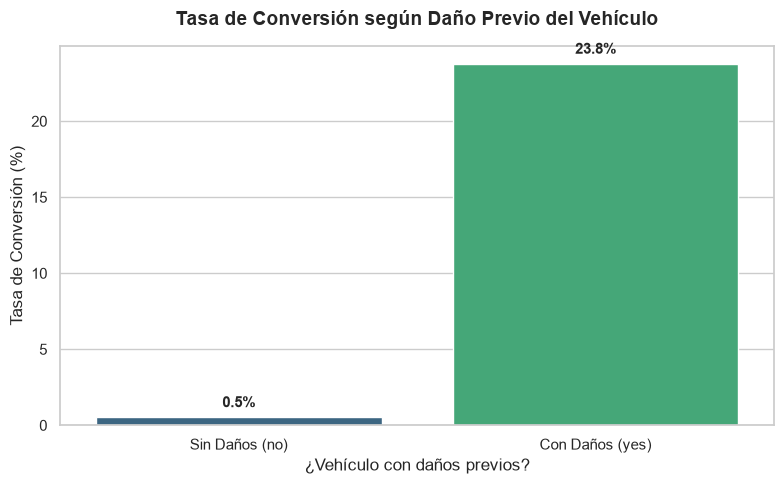

In [6]:
# Calculamos la tasa de conversión (porcentaje de Response = 1) según daño previo
conversion_dano = df_clean.groupby('Vehicle_Damage')['Response'].mean() * 100

# Configuramos el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Creamos un gráfico de barras mapeando directamente los nombres limpios en el eje X
ax = sns.barplot(
    x=['Sin Daños (no)', 'Con Daños (yes)'], 
    y=conversion_dano.values, 
    hue=['Sin Daños (no)', 'Con Daños (yes)'], 
    palette='viridis', 
    legend=False
)

# Personalizamos títulos y etiquetas
plt.title('Tasa de Conversión según Daño Previo del Vehículo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('¿Vehículo con daños previos?', fontsize=12)
plt.ylabel('Tasa de Conversión (%)', fontsize=12)

# Agregamos los porcentajes arriba de cada barra para facilitar la lectura
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

# Ajustamos los márgenes y mostramos el gráfico limpio
plt.tight_layout()
plt.show()

<div style="background-color: #EAFAF1; border-left: 4px solid #27AE60; padding: 12px; border-radius: 4px; margin-top: 15px;">
  <p style="color: #145A32; margin: 0; font-family: sans-serif;">
    💡 <strong>Insight de Negocio:</strong> Existe una diferencia drástica en la propensión de compra. Los clientes con <strong>vehículos dañados previamente</strong> registran una conversión del <strong>23.8%</strong>, frente a un magro <strong>0.5%</strong> en clientes sin daños. Esto demuestra que la venta cruzada no se impulsa por el producto en sí, sino por la conciencia de riesgo y la experiencia previa del siniestro.
  </p>
</div>